In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



In [2]:
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (12, 4)
plt.rcParams["axes.titlesize"] = 11

_here = Path.cwd()
LAB_DIR = _here
for p in (_here, _here / "Lab_2"):
    if (p / "Lab2_Коксование масла ГПА ст. №35 КС-18А.parquet").exists() or (
        p / "Lab2_Коксование масла ГПА ст. №35 КС-18А.txt"
    ).exists():
        LAB_DIR = p
        break
DATA_PARQUET = LAB_DIR / "Lab2_Коксование масла ГПА ст. №35 КС-18А.parquet"
DATA_TXT = LAB_DIR / "Lab2_Коксование масла ГПА ст. №35 КС-18А.txt"

In [3]:
def load_lab2_table() -> pd.DataFrame:
    if DATA_PARQUET.exists():
        df = pd.read_parquet(DATA_PARQUET)
    elif DATA_TXT.exists():
        df = pd.read_csv(
            DATA_TXT,
            sep=",",
            decimal=",",
            low_memory=False,
        )
    df["TS"] = pd.to_datetime(df["TS"], errors="coerce")
    df = df.sort_values("TS").reset_index(drop=True)
    return df


raw = load_lab2_table()
raw.shape, raw["TS"].min(), raw["TS"].max()

((2040, 119),
 Timestamp('2022-03-25 08:29:59.999999+0000', tz='UTC'),
 Timestamp('2022-03-26 01:28:59.999999+0000', tz='UTC'))

In [4]:
raw

,row,TS,Lab2_G1_N1,Lab2_G1_N2,Lab2_G1_N3,Lab2_G1_P2,Lab2_G1_T4ср,Lab2_G1_T1,Lab2_G1_T607,Lab2_G1_T600,...,Lab2_AVOM_AVOMN1,Lab2_Kp,Lab2_hGPA,Lab2_Kran_5,Lab2_Kran_2,Lab2_Kran_6,Lab2_U_Kran_GPA_A_APK,Lab2_Kran_1,Lab2_Kran_4,Lab2_q
0,1,2022-03-25 08:29:59.999999+00:00,0,0,0,0.03,53.7,7.9,25.8,22.02,...,1,0.89,0.3,0,1,0,0,1,0,51.5
1,2,2022-03-25 08:29:59.999999+00:00,0,0,0,0.03,53.7,7.9,25.8,22.02,...,1,0.89,0.3,0,1,0,0,1,0,51.5
2,3,2022-03-25 08:31:00+00:00,0,0,0,0.04,55.3,8.1,25.8,21.72,...,1,0.89,0.3,0,1,0,0,1,0,51.5
3,4,2022-03-25 08:31:00+00:00,0,0,0,0.04,55.3,8.1,25.8,21.72,...,1,0.89,0.3,0,1,0,0,1,0,51.5
4,5,2022-03-25 08:32:00+00:00,0,0,0,0.04,56.8,8.3,25.9,21.36,...,1,0.89,0.3,0,1,0,0,1,0,51.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2035,2036,2022-03-26 01:26:59.999999+00:00,0,0,0,0.03,81.6,2.4,31.4,26.92,...,1,0.00,0.0,1,0,0,0,0,0,0.0
2036,2037,2022-03-26 01:27:59.999999+00:00,0,0,0,0.05,80.4,2.4,31.2,26.77,...,1,0.00,0.0,1,0,0,0,0,0,0.0
2037,2038,2022-03-26 01:27:59.999999+00:00,0,0,0,0.05,80.4,2.4,31.2,26.77,...,1,0.00,0.0,1,0,0,0,0,0,0.0
2038,2039,2022-03-26 01:28:59.999999+00:00,0,0,0,0.03,79.0,2.4,31.1,26.63,...,1,0.00,0.0,1,0,0,0,0,0,0.0


In [5]:
raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 2040 entries, 0 to 2039
Columns: 119 entries, row to Lab2_q
dtypes: datetime64[us, UTC](1), float64(86), int64(32)
memory usage: 1.9 MB


In [6]:
len(raw["TS"].unique())

1020

In [7]:
raw.isna().sum().unique()

array([0])

### Дубликаты по времени

В выгрузке присутствуют две строки на одну метку времени. Для ряда оставляем **одну** запись на timestamp, чтобы не исказить частоту и автокорреляцию. Используем **последнюю** строку в группе.

In [8]:
dup_per_ts = raw.groupby("TS").size()
multi = dup_per_ts[dup_per_ts > 1]
print("Меток времени с >1 строкой:", len(multi), "из", raw["TS"].nunique())

df = raw.drop_duplicates(subset=["TS"], keep="last").reset_index(drop=True)
df = df.set_index("TS").sort_index()
df.shape

Меток времени с >1 строкой: 1020 из 1020


(1020, 118)

In [9]:
numeric_cols = [
    c for c in df.select_dtypes(include=[np.number]).columns
    if c != "row"
]


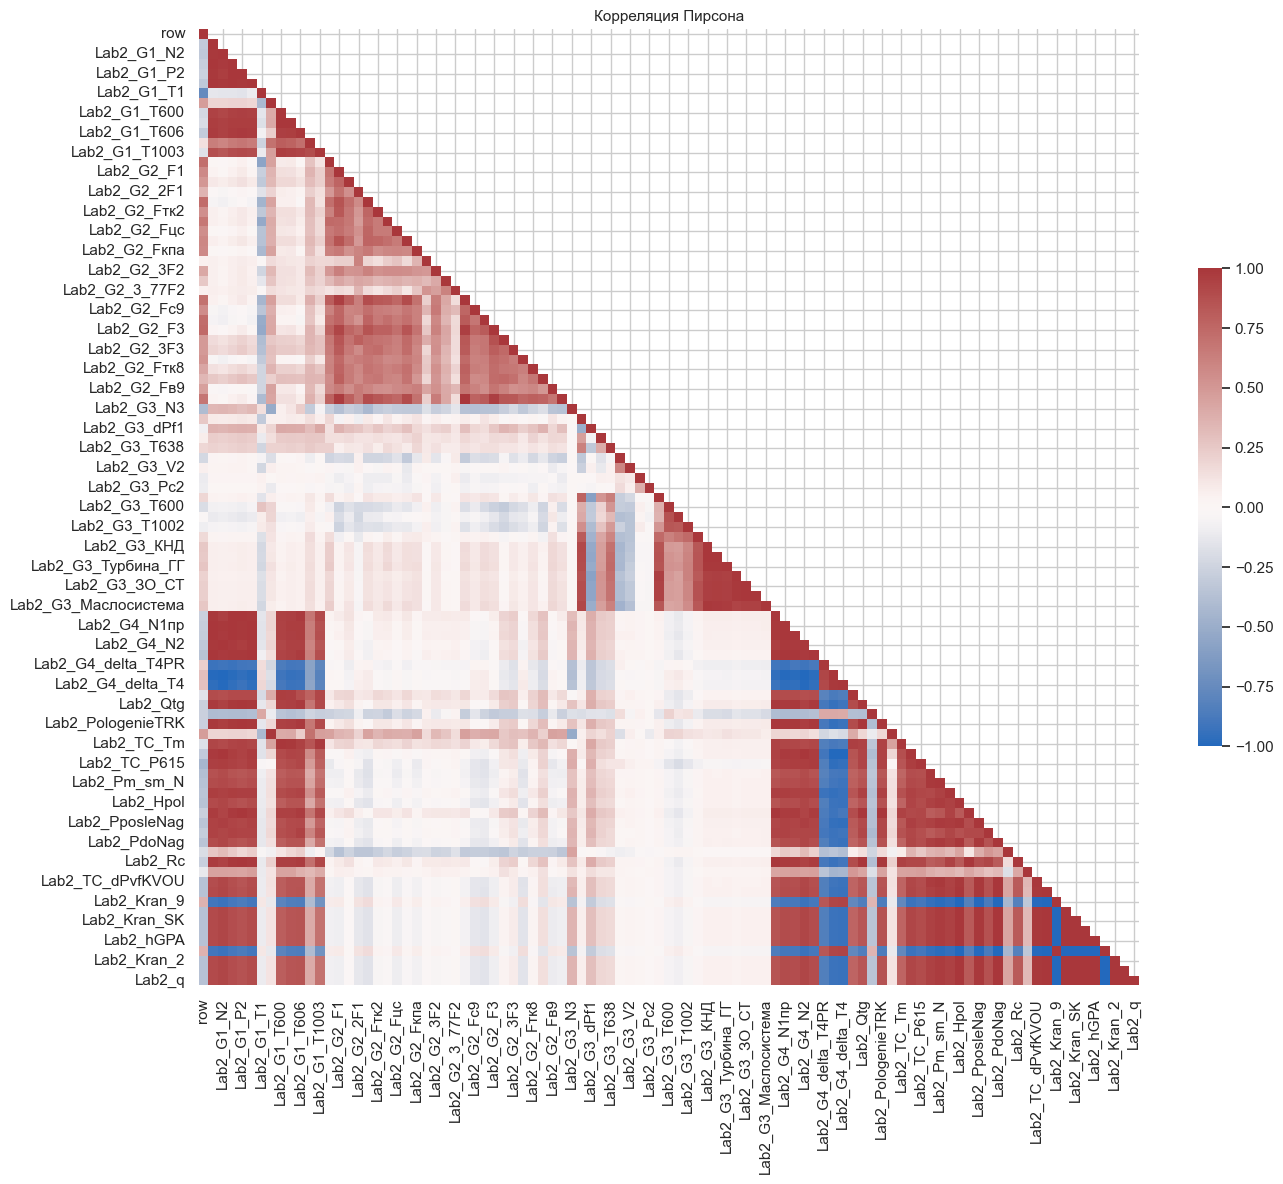

In [10]:
_var = df.var(numeric_only=True)
corr_cols = _var[_var > 1e-12].index.tolist()
CORR = df[corr_cols].corr()

plt.figure(figsize=(14, 12))
mask = np.triu(np.ones_like(CORR, dtype=bool), k=1)
sns.heatmap(
    CORR,
    mask=mask,
    cmap="vlag",
    center=0,
    linewidths=0,
    cbar_kws={"shrink": 0.5},
)
plt.title("Корреляция Пирсона")
plt.tight_layout()
plt.show()


def pick_low_cross_correlation(corr: pd.DataFrame, k: int = 5) -> list[str]:
    """Жадно: добавляем признак с минимальным max_{j in S} |corr(i,j)| к уже выбранным S."""
    cols = list(corr.columns)
    A = corr.abs().reindex(index=cols, columns=cols)
    m = A.to_numpy().copy()
    np.fill_diagonal(m, np.nan)
    mean_abs = np.nanmean(m, axis=1)
    first = cols[int(np.nanargmin(mean_abs))]
    selected = [first]
    pool = [c for c in cols if c != first]

    while len(selected) < k and pool:
        best_c, best_score = None, np.inf
        for c in pool:
            score = max(float(A.loc[c, s]) for s in selected)
            if score < best_score:
                best_score, best_c = score, c
        selected.append(best_c)
        pool.remove(best_c)
    return selected


In [11]:


N_PLOT = min(10, len(corr_cols))
plot_cols = pick_low_cross_correlation(CORR, k=N_PLOT)
print("Колонки для графиков (слабо коррелируют между собой):", plot_cols)
try:
    from IPython.display import display as _d
    _d(CORR.loc[plot_cols, plot_cols].style.format("{:.2f}"))
except Exception:
    print(CORR.loc[plot_cols, plot_cols])


Колонки для графиков (слабо коррелируют между собой): ['Lab2_G3_Pc2', 'Lab2_TC_Ptgdg', 'Lab2_G2_Fтк4', 'Lab2_G3_V2', 'Lab2_G3_Pm', 'Lab2_dev', 'Lab2_G3_dPf1', 'Lab2_TdoNag', 'Lab2_G1_T607', 'Lab2_G3_T600']


,Lab2_G3_Pc2,Lab2_TC_Ptgdg,Lab2_G2_Fтк4,Lab2_G3_V2,Lab2_G3_Pm,Lab2_dev,Lab2_G3_dPf1,Lab2_TdoNag,Lab2_G1_T607,Lab2_G3_T600
Lab2_G3_Pc2,1.00,0.00,-0.03,0.07,0.01,0.02,-0.05,-0.04,-0.11,-0.04
Lab2_TC_Ptgdg,0.00,1.00,-0.04,-0.05,-0.16,-0.17,-0.16,-0.24,-0.11,0.21
Lab2_G2_Fтк4,-0.03,-0.04,1.00,0.01,0.13,0.05,0.22,-0.23,0.27,-0.05
Lab2_G3_V2,0.07,-0.05,0.01,1.00,-0.12,0.02,0.06,-0.07,0.07,-0.31
Lab2_G3_Pm,0.01,-0.16,0.13,-0.12,1.00,0.10,-0.06,-0.03,0.15,0.20
Lab2_dev,0.02,-0.17,0.05,0.02,0.10,1.00,0.15,-0.18,0.12,-0.06
Lab2_G3_dPf1,-0.05,-0.16,0.22,0.06,-0.06,0.15,1.00,0.01,0.19,-0.32
Lab2_TdoNag,-0.04,-0.24,-0.23,-0.07,-0.03,-0.18,0.01,1.00,-0.08,0.02
Lab2_G1_T607,-0.11,-0.11,0.27,0.07,0.15,0.12,0.19,-0.08,1.00,0.20
Lab2_G3_T600,-0.04,0.21,-0.05,-0.31,0.20,-0.06,-0.32,0.02,0.20,1.00


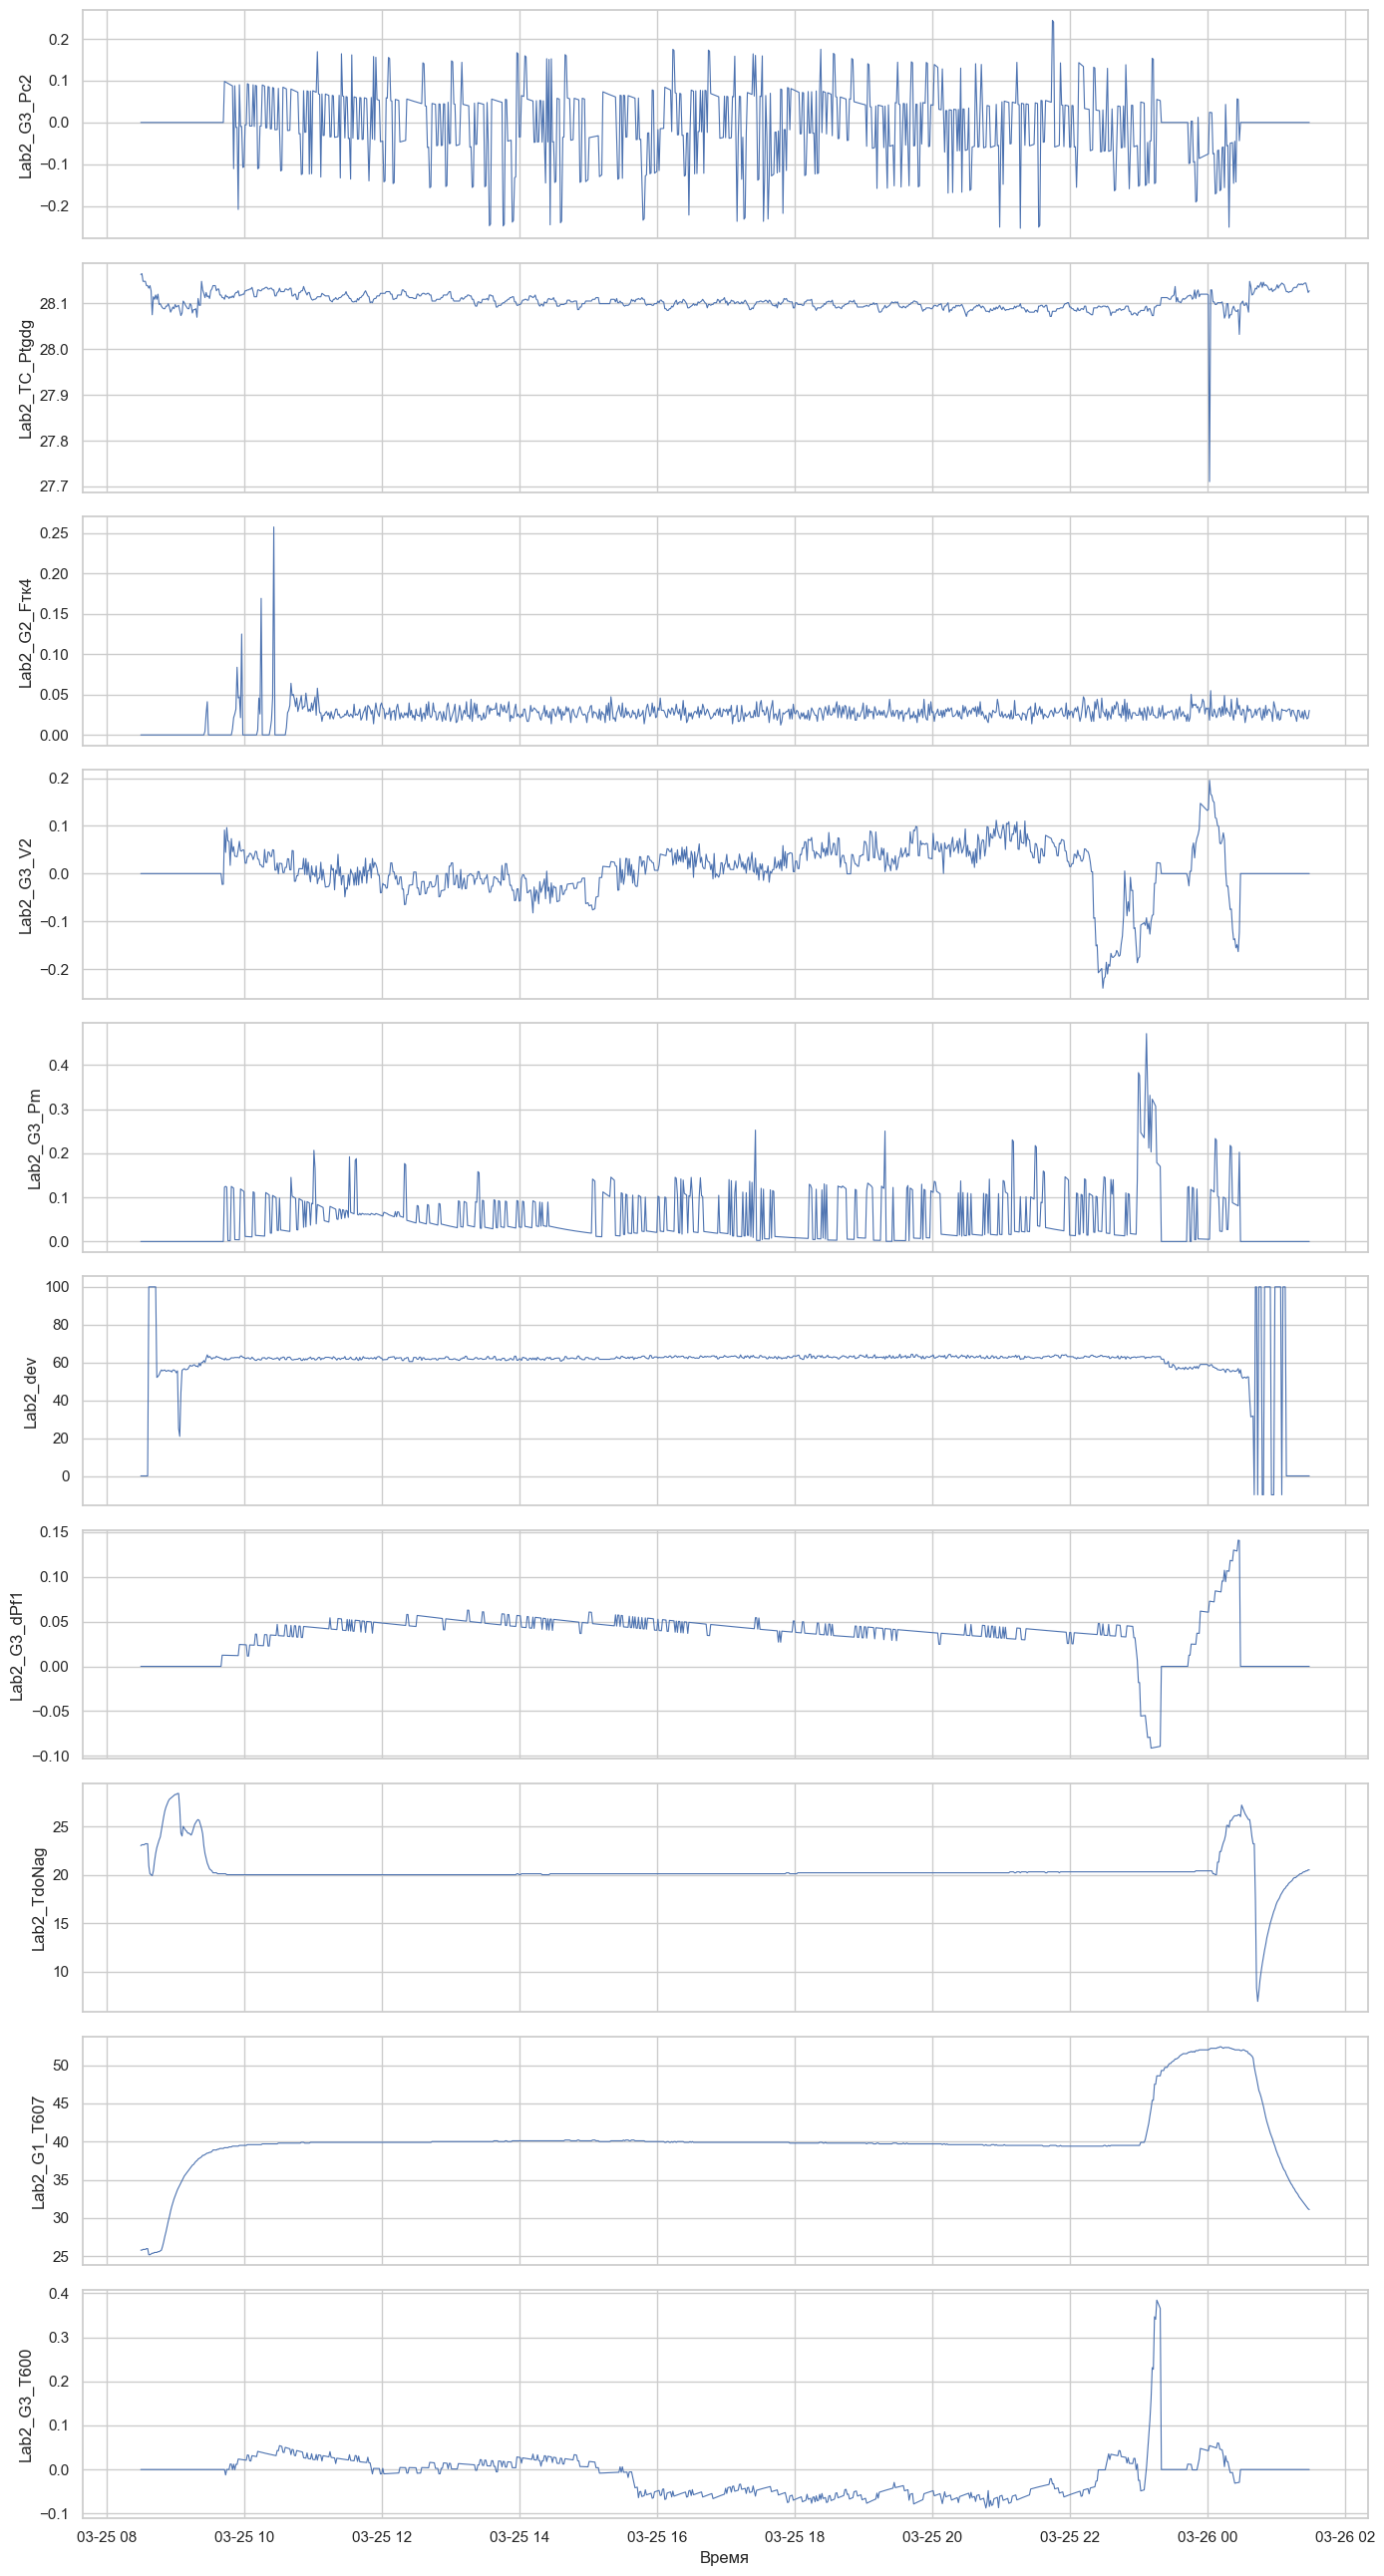

In [12]:
fig, axes = plt.subplots(len(plot_cols), 1, figsize=(14, 2.6 * len(plot_cols)), sharex=True)
if len(plot_cols) == 1:
    axes = [axes]
for ax, col in zip(axes, plot_cols):
    ax.plot(df.index, df[col], lw=0.8, color="C0")
    ax.set_ylabel(col)
axes[-1].set_xlabel("Время")
plt.tight_layout()
plt.show()

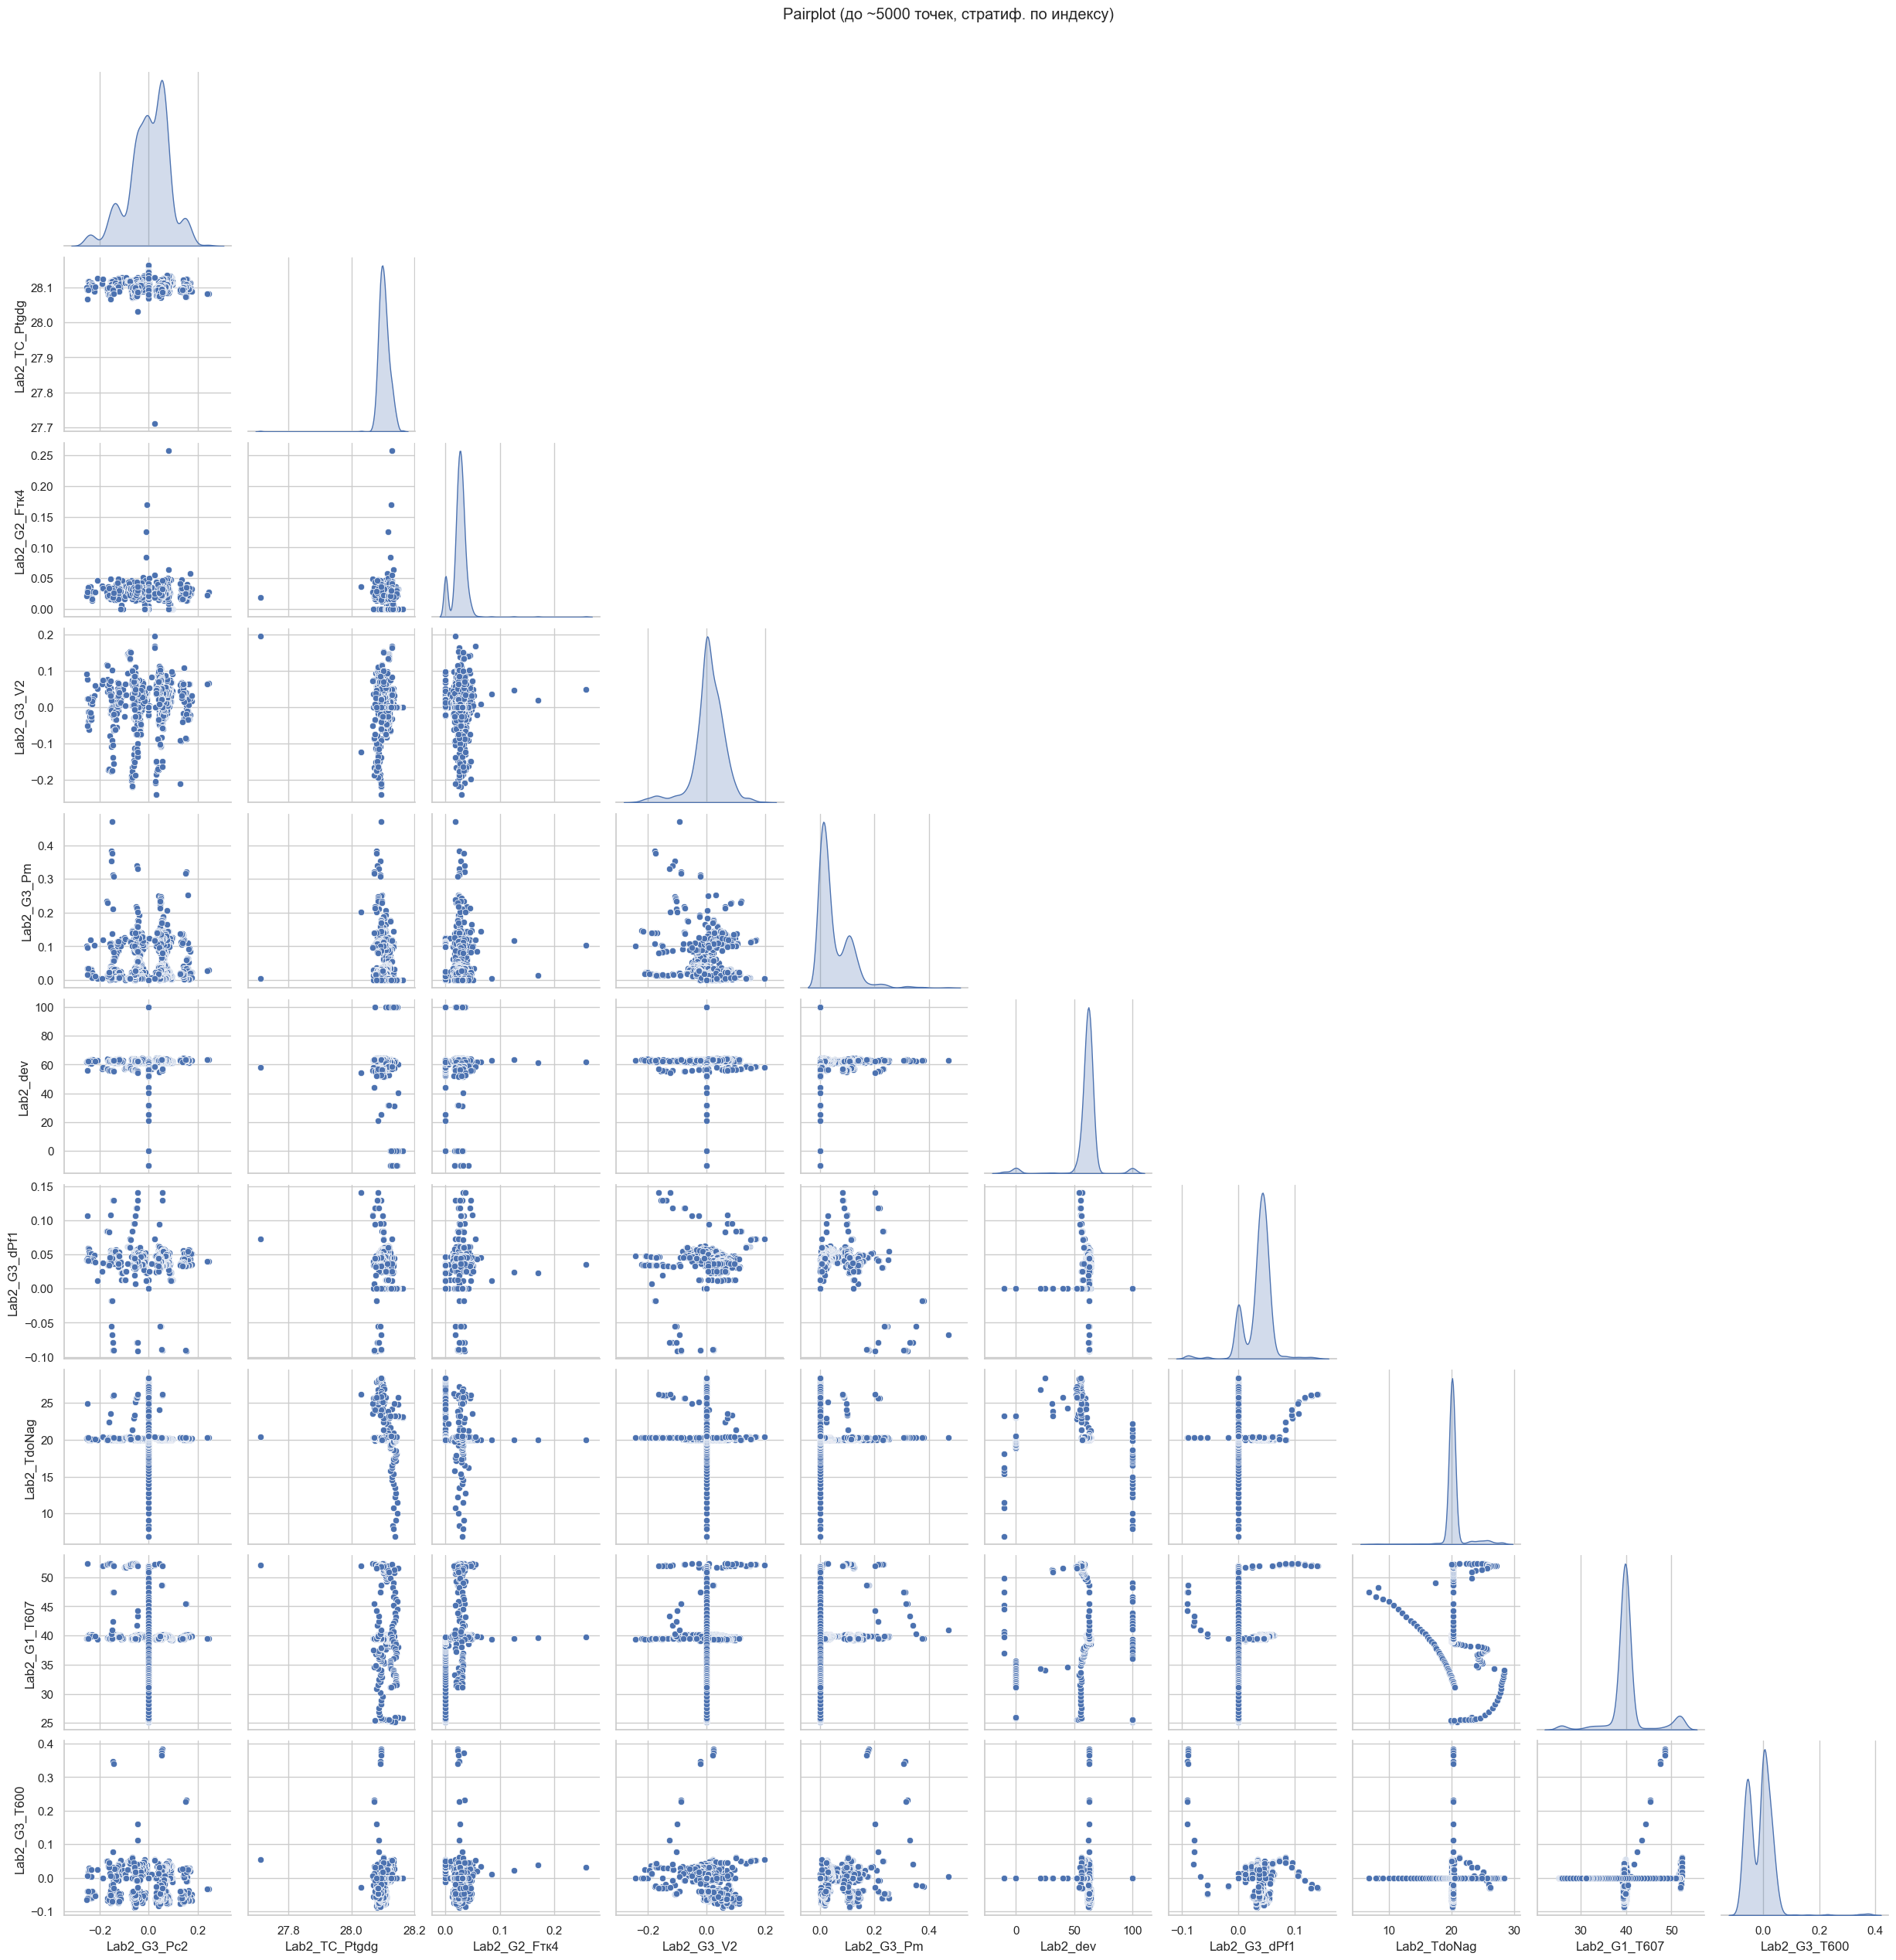

In [13]:
subset = df[plot_cols].dropna()
if subset.shape[1] >= 2:
    g = sns.pairplot(subset.iloc[:: max(1, len(subset) // 5000)], diag_kind="kde", corner=True)
    g.fig.suptitle("Pairplot (до ~5000 точек, стратиф. по индексу)", y=1.02)
    plt.show()

In [20]:
_var_all = df.var(numeric_only=True)
const_cols = _var_all[_var_all <= 1e-12].index.tolist()

_num = df.select_dtypes(include=[np.number]).drop(columns=const_cols, errors="ignore")
_nun = _num.nunique(dropna=True)
binary_cols = _nun[_nun <= 2].index.tolist()
continuous_cols = [c for c in _num.columns if c not in binary_cols]

regime_signals = df[binary_cols].copy()
df_cont = df[continuous_cols].copy()

print(f"Константных колонок отброшено: {len(const_cols)}")
print(f"Бинарных сигналов (regime_signals): {len(binary_cols)}")
print(f"Непрерывных кандидатов: {len(continuous_cols)}")
print("Бинарные сигналы (для валидации кластеров):")
print(binary_cols)

Константных колонок отброшено: 21
Бинарных сигналов (regime_signals): 11
Непрерывных кандидатов: 86
Бинарные сигналы (для валидации кластеров):
['Lab2_TC_dPvfKVOU', 'Lab2_Kran_12', 'Lab2_Kran_9', 'Lab2_U_Kran_GPA_A_OGK', 'Lab2_Kran_SK', 'Lab2_Kp', 'Lab2_hGPA', 'Lab2_Kran_5', 'Lab2_Kran_2', 'Lab2_Kran_1', 'Lab2_q']


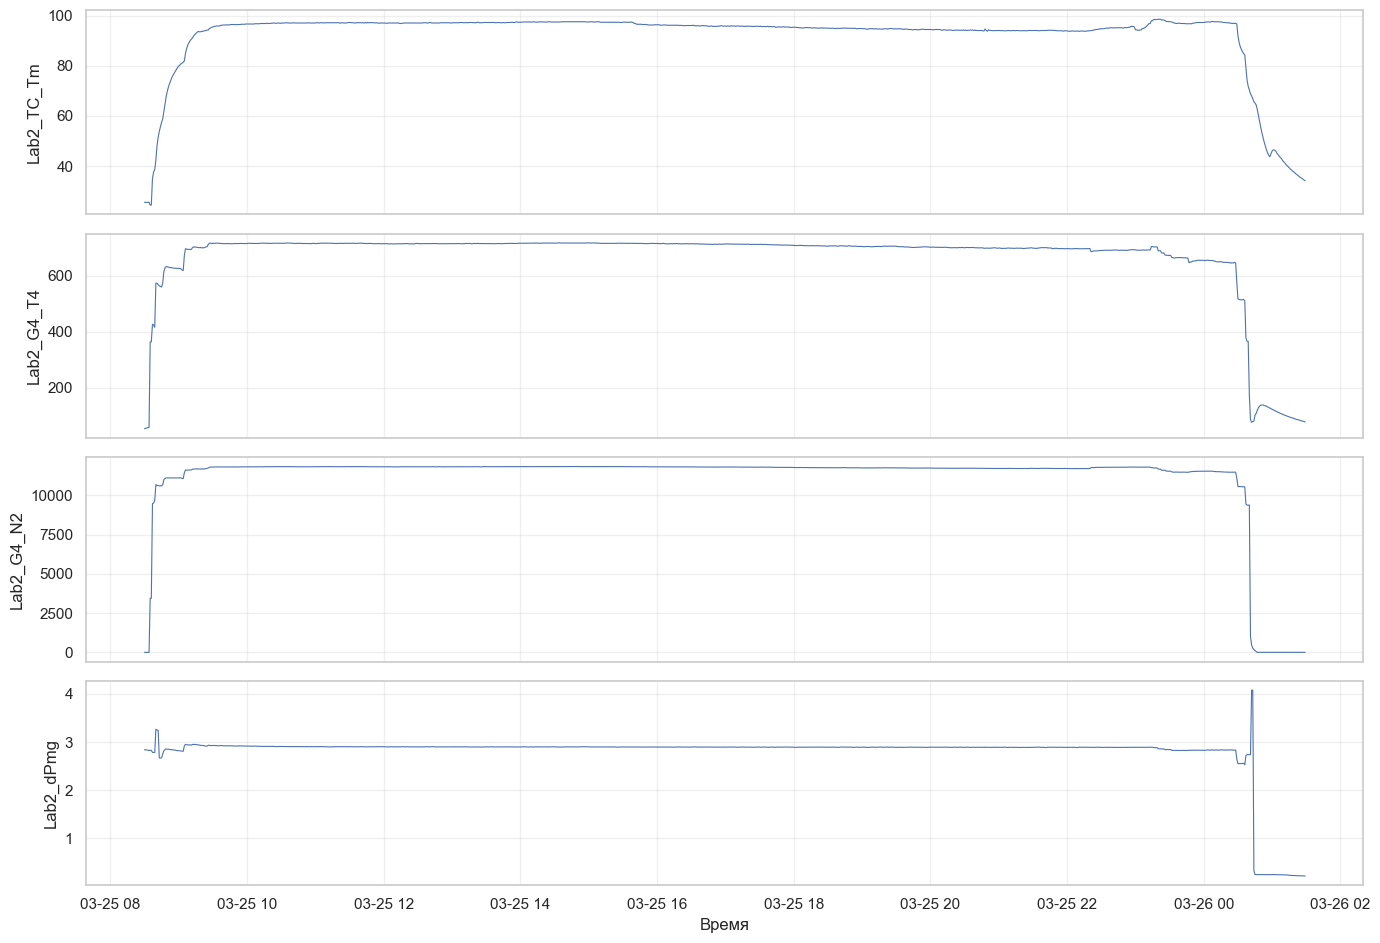

               min     median        max       std     cv  share_zero
Lab2_TC_Tm  24.400     95.900     98.600    13.417  0.146       0.000
Lab2_G4_T4  54.430    709.690    717.830   140.101  0.210       0.000
Lab2_G4_N2   0.000  11793.875  11837.900  2651.517  0.239       0.047
Lab2_dPmg    0.214      2.893      4.079     0.555  0.200       0.000


In [19]:
CANDIDATES = ["Lab2_TC_Tm", "Lab2_G4_T4", "Lab2_G4_N2", "Lab2_dPmg"]
CANDIDATES = [c for c in CANDIDATES if c in df_cont.columns]

fig, axes = plt.subplots(len(CANDIDATES), 1, figsize=(14, 2.4 * len(CANDIDATES)), sharex=True)
for ax, col in zip(axes, CANDIDATES):
    ax.plot(df_cont.index, df_cont[col], lw=0.8)
    ax.set_ylabel(col)
    ax.grid(True, alpha=0.3)
axes[-1].set_xlabel("Время")
plt.tight_layout()
plt.show()

stats = pd.DataFrame({
    "min": df_cont[CANDIDATES].min(),
    "median": df_cont[CANDIDATES].median(),
    "max": df_cont[CANDIDATES].max(),
    "std": df_cont[CANDIDATES].std(),
    "cv": df_cont[CANDIDATES].std() / (df_cont[CANDIDATES].abs().mean() + 1e-9),
    "share_zero": (df_cont[CANDIDATES] == 0).mean(),
})
print(stats.round(3))

Целевой ряд: Lab2_TC_Tm
Длина: 1020 точек, шаг ~1 мин, период 2022-03-25 08:29:59.999999+00:00 → 2022-03-26 01:28:59.999999+00:00
min=24.400, median=95.900, max=98.600, std=13.417


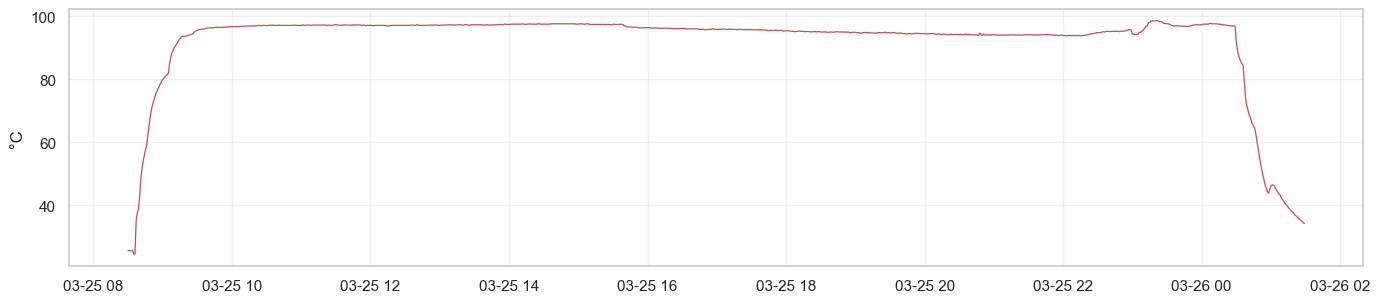

In [18]:
TARGET_COL = "Lab2_TC_Tm"
y = df_cont[TARGET_COL].astype(float).copy()
y.name = TARGET_COL

print(f"Целевой ряд: {TARGET_COL}")
print(f"Длина: {len(y)} точек, шаг ~1 мин, период {y.index.min()} → {y.index.max()}")
print(f"min={y.min():.3f}, median={y.median():.3f}, max={y.max():.3f}, std={y.std():.3f}")

fig, ax = plt.subplots(figsize=(14, 3.2))
ax.plot(y.index, y.values, lw=0.9, color="C3")
ax.set_ylabel("°C")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [37]:
import nolds

y_arr = y.values.astype(float)

H_rs  = nolds.hurst_rs(y_arr, nvals=None, fit="RANSAC", debug_data=False)
H_dfa = nolds.dfa(y_arr, nvals=None, fit_exp="RANSAC", debug_data=False)

print(f"Показатель Хёрста (R/S) : H = {H_rs:.4f}")
print(f"Показатель Хёрста (DFA) : H = {H_dfa:.4f}")

if H_rs > 0.6:
    interp = "персистентный процесс (долгая положительная память)"
elif H_rs < 0.4:
    interp = "антиперсистентный процесс (возвраты к среднему)"
else:
    interp = "близок к случайному блужданию (кратковременная память)"
print(f"\nИнтерпретация (R/S): {interp}")

Показатель Хёрста (R/S) : H = 0.9406
Показатель Хёрста (DFA) : H = 1.8149

Интерпретация (R/S): персистентный процесс (долгая положительная память)


In [38]:
from nolds.measures import logarithmic_n
import numpy as np

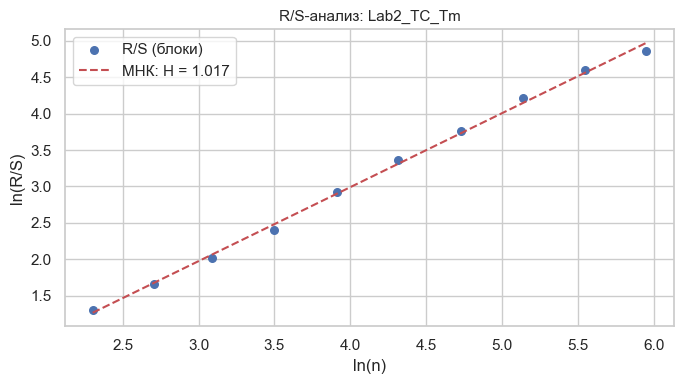

In [41]:
def hurst_rs_plot(x, nvals=None, title="R/S-анализ"):

    N = len(x)
    if nvals is None:
        nvals = logarithmic_n(10, N // 2, 1.5)
    nvals = np.array([n for n in nvals if n >= 8])

    rs_vals = []
    for n in nvals:
        blocks = [x[i:i+n] for i in range(0, N - n + 1, n)]
        rs_block = []
        for b in blocks:
            b = np.asarray(b, dtype=float)
            mean = b.mean()
            dev = np.cumsum(b - mean)
            R = dev.max() - dev.min()
            S = b.std(ddof=1)
            if S > 0:
                rs_block.append(R / S)
        if rs_block:
            rs_vals.append(np.mean(rs_block))

    nvals_ok = nvals[:len(rs_vals)]
    log_n = np.log(nvals_ok)
    log_rs = np.log(rs_vals)
    H_est, intercept = np.polyfit(log_n, log_rs, 1)

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.scatter(log_n, log_rs, s=30, label="R/S (блоки)")
    x_line = np.linspace(log_n.min(), log_n.max(), 100)
    ax.plot(x_line, H_est * x_line + intercept, "r--",
            label=f"МНК: H = {H_est:.3f}")
    ax.set_xlabel("ln(n)")
    ax.set_ylabel("ln(R/S)")
    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    plt.show()
    return H_est

H_rs_plot = hurst_rs_plot(y_arr, title=f"R/S-анализ: {TARGET_COL}")


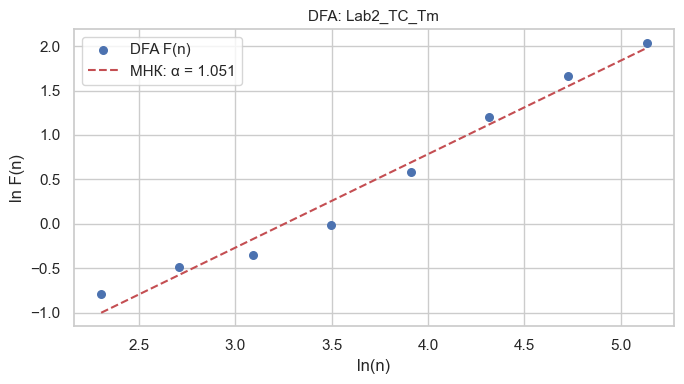


DFA α = 1.0515


In [40]:
from nolds.measures import logarithmic_n
import numpy as np


def dfa_plot(x, nvals=None, order=1, title="DFA"):
    """Строит log-log DFA-график с оценкой α (≈ H для монофрактальных рядов)."""

    N = len(x)
    if nvals is None:
        nvals = logarithmic_n(10, N // 4, 1.5)
    nvals = np.array([n for n in nvals if n >= 8])

    flucts = []
    for n in nvals:
        blocks = [x[i:i+n] for i in range(0, N - n + 1, n)]
        f_sq = []
        for b in blocks:
            b = np.asarray(b, dtype=float)
            t = np.arange(len(b))
            coeffs = np.polyfit(t, b, order)
            trend = np.polyval(coeffs, t)
            f_sq.append(np.mean((b - trend) ** 2))
        flucts.append(np.sqrt(np.mean(f_sq)))

    log_n = np.log(nvals)
    log_f = np.log(flucts)
    alpha, intercept = np.polyfit(log_n, log_f, 1)

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.scatter(log_n, log_f, s=30, label="DFA F(n)")
    x_line = np.linspace(log_n.min(), log_n.max(), 100)
    ax.plot(x_line, alpha * x_line + intercept, "r--",
            label=f"МНК: α = {alpha:.3f}")
    ax.set_xlabel("ln(n)")
    ax.set_ylabel("ln F(n)")
    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    plt.show()
    return alpha

alpha_dfa = dfa_plot(y_arr, title=f"DFA: {TARGET_COL}")
print(f"\nDFA α = {alpha_dfa:.4f}")

In [42]:
from statsmodels.tsa.stattools import acf as _acf
import warnings

def first_acf_zero(x, nlags=200):
    """Индекс первого перехода ACF через ноль."""
    a = _acf(x, nlags=nlags, fft=True)
    for i in range(1, len(a)):
        if a[i] <= 0:
            return i
    return nlags

tau_acf = first_acf_zero(y_arr)
print(f"Первый ноль ACF: lag = {tau_acf}")

TAU_ROUGH = max(tau_acf, 1)
M_ROUGH   = 3

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    lyap_rough = nolds.lyap_r(
        y_arr,
        emb_dim=M_ROUGH,
        lag=TAU_ROUGH,
        min_tsep=TAU_ROUGH,
        trajectory_len=20,
    )

print(f"\nСтарший показатель Ляпунова")
print("$\lambda_{1}$ ≈ {lyap_rough:.5f}  ($\tau$={TAU_ROUGH}, m={M_ROUGH})")

if lyap_rough > 0:
    print("вложение Такенса оправдано")
else:
    print("ряд, скорее, стохастический")

Первый ноль ACF: lag = 56

Старший показатель Ляпунова
$\lambda_{1}$ ≈ {lyap_rough:.5f}  ($	au$={TAU_ROUGH}, m={M_ROUGH})
вложение Такенса оправдано


<>:29: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
<>:29: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
C:\Users\krellQ\AppData\Local\Temp\ipykernel_19856\805556648.py:29: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
  print("$\lambda_{1}$ ≈ {lyap_rough:.5f}  ($\tau$={TAU_ROUGH}, m={M_ROUGH})")


<>:48: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
<>:48: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
C:\Users\krellQ\AppData\Local\Temp\ipykernel_19856\2920467591.py:48: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
  label=f"МНК: $\lambda_{1}$ ≈ {slope:.4f}")


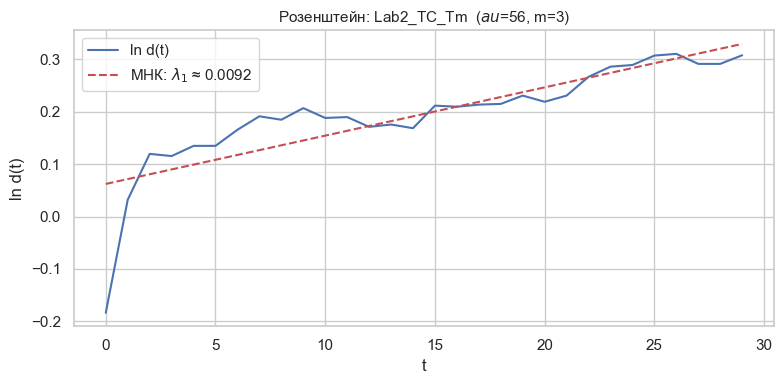

In [33]:
def lyap_plot(x, tau, emb_dim, traj_len=30, title="Алгоритм Розенштейна"):

    N = len(x)
    n_pts = N - (emb_dim - 1) * tau
    if n_pts <= 0:
        return

    # построение матрицы вложения
    X = np.stack([x[i * tau: i * tau + n_pts] for i in range(emb_dim)], axis=1)

    from sklearn.neighbors import BallTree
    tree = BallTree(X)
    min_tsep = tau

    log_d = np.full(traj_len, np.nan)
    counts = np.zeros(traj_len)

    for idx in range(len(X)):
        dists, inds = tree.query(X[idx:idx+1], k=2 + min_tsep * emb_dim)
        inds = inds[0]
        # фильтр по временному разделению
        valid = [j for j in inds[1:] if abs(j - idx) > min_tsep]
        if not valid:
            continue
        nn = valid[0]
        for k in range(traj_len):
            i1, i2 = idx + k, nn + k
            if i1 >= len(X) or i2 >= len(X):
                break
            d = np.linalg.norm(X[i1] - X[i2])
            if d > 0:
                if np.isnan(log_d[k]):
                    log_d[k] = np.log(d)
                else:
                    log_d[k] += np.log(d)
                counts[k] += 1

    ok = counts > 0
    log_d[ok] /= counts[ok]

    t = np.arange(traj_len)
    ok_finite = ok & np.isfinite(log_d)
    slope, intercept = np.polyfit(t[ok_finite], log_d[ok_finite], 1)

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(t[ok_finite], log_d[ok_finite], lw=1.5, label="ln d(t)")
    ax.plot(t[ok_finite], slope * t[ok_finite] + intercept, "r--",
            label=f"МНК: $\lambda_{1}$ ≈ {slope:.4f}")
    ax.set_xlabel("t")
    ax.set_ylabel("ln d(t)")
    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    plt.show()
    return slope

lyap_slope = lyap_plot(
    y_arr, tau=TAU_ROUGH, emb_dim=M_ROUGH,
    traj_len=30,
    title=f"Розенштейн: {TARGET_COL}  ($\tau$={TAU_ROUGH}, m={M_ROUGH})",
)